In [9]:
import nltk
from nltk.corpus import wordnet

# Test basic WordNet functionality (synonyms for "nlp")
synsets = wordnet.synsets("natural language processing")
print("✅ WordNet is installed!")
print(f"Found {len(synsets)} synsets for 'natural language processing':")
for syn in synsets[:2]:  # Print first 2 synonyms/definitions
    print(f"- {syn.name()}: {syn.definition()}")

✅ WordNet is installed!
Found 0 synsets for 'natural language processing':


In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import numpy as np

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple mps 😃")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else: 
    device = torch.device("cpu")
    print("Using slow cpu😔")

print(f"Current device: {device}")


Using Apple mps 😃
Current device: mps


In [5]:
# Text preprocessing tools
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    precision_score,
    recall_score
)
from sklearn.utils import resample
from sklearn.pipeline import Pipeline

# Set random seed for reproducibility
np.random.seed(42)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/talosmann/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/talosmann/nltk_data...
[nltk_data] Error downloading 'wordnet' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/corpora/wordnet.zip>:   Remote end
[nltk_data]     closed connection without response


In [6]:
from sklearn.datasets import fetch_20newsgroups
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
# Load a subset of 20 Newsgroups (simpler for binary/multi-class testing)
# We'll pick 2 categories for binary classification (easier to measure precision/recall)
categories = ['comp.graphics', 'rec.sport.baseball']
newsgroups = fetch_20newsgroups(
    subset='all',  # use all data (train + test)
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  # clean irrelevant text
    random_state=42
)

# Convert to DataFrame for easy preprocessing
import pandas as pd
df = pd.DataFrame({
    'text': newsgroups.data,
    'label': newsgroups.target  # 0 = comp.graphics, 1 = rec.sport.baseball
})

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")
# Output: ~1800 samples, balanced across 2 classes

Dataset shape: (1967, 2)
Class distribution:
label
1    994
0    973
Name: count, dtype: int64


In [10]:
def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Tokenize (split into words) and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # 4. Lemmatization (reduce words to root form)
    words = [lemmatizer.lemmatize(word) for word in words]
    # 5. Rejoin words into text
    return ' '.join(words)

# Apply preprocessing to the dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Verify preprocessing
print("Original text:", df['text'].iloc[0])
print("Cleaned text:", df['cleaned_text'].iloc[0])

Original text: : Are there significant differences between V2.01 and V2.00 ?
: Thank you for helping


No.  As I recall, the only differences are in the 3ds.set parameters - some
of the defaults have changed slightly.  I'll look when I get home and let
you know, but there isn't enough to actually warrant upgrading.
Cleaned text: significant difference v v thank helping recall difference dsset parameter default changed slightly ill look get home let know isnt enough actually warrant upgrading


In [11]:
# Split data (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], 
    df['label'], 
    test_size=0.2,  # 20% test data
    stratify=df['label'],  # critical for balanced evaluation
    random_state=42
)

# TF-IDF Vectorizer (convert text to numerical features)
# Optimize TF-IDF parameters to avoid overfitting
tfidf = TfidfVectorizer(
    max_features=5000,  # limit features to top 5000 (reduce dimensionality)
    ngram_range=(1, 2),  # use unigrams + bigrams (e.g., "great product")
    min_df=5,  # ignore words appearing in <5 docs (reduce noise)
    max_df=0.95  # ignore words appearing in >95% docs (too common)
)

# Fit TF-IDF on training data only (avoid data leakage!)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Train features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")

Train features shape: (1573, 4229)
Test features shape: (394, 4229)


In [12]:
# Base Logistic Regression model
base_model = LogisticRegression(random_state=42)
base_model.fit(X_train_tfidf, y_train)

# Evaluate base model
y_pred_base = base_model.predict(X_test_tfidf)

# Calculate precision and recall
base_precision = precision_score(y_test, y_pred_base)
base_recall = recall_score(y_test, y_pred_base)

print("Base Model Performance:")
print(f"Precision: {base_precision:.4f}")
print(f"Recall: {base_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

Base Model Performance:
Precision: 0.9314
Recall: 0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       195
           1       0.93      0.95      0.94       199

    accuracy                           0.94       394
   macro avg       0.94      0.94      0.94       394
weighted avg       0.94      0.94      0.94       394



In [14]:
# Define parameter grid (focus on regularization to avoid overfitting)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength (smaller=C=stronger regularization)
  # L1 (Lasso) = feature selection, L2 (Ridge) = weight shrinkage
    'solver': ['liblinear'],  # Only solver that supports L1 penalty
    'class_weight': [None, 'balanced']  # Address class imbalance (if any)
}

# Stratified K-Fold cross-validation (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search (optimize for F1-score, balance of precision/recall)
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',  # Use f1 for balanced precision/recall (use 'precision' or 'recall' if prioritizing one)
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Train on training data
grid_search.fit(X_train_tfidf, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate optimized model
y_pred_best = best_model.predict(X_test_tfidf)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)

print("\nOptimized Model Performance:")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 10, 'class_weight': 'balanced', 'solver': 'liblinear'}

Optimized Model Performance:
Precision: 0.9412
Recall: 0.9648

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       195
           1       0.94      0.96      0.95       199

    accuracy                           0.95       394
   macro avg       0.95      0.95      0.95       394
weighted avg       0.95      0.95      0.95       394



In [16]:
# 1. Stronger regularization (smaller C in Logistic Regression)
overfit_fix_model = LogisticRegression(
    C=0.01,  # Smaller C = stronger regularization
    random_state=42
)

# 2. Reduce feature dimensionality (fewer TF-IDF features)
tfidf_reduced = TfidfVectorizer(max_features=1000, min_df=10)
X_train_reduced = tfidf_reduced.fit_transform(X_train)

# 3. Add more training data (most effective if possible)

# Train and evaluate
overfit_fix_model.fit(X_train_reduced, y_train)
X_test_reduced = tfidf_reduced.transform(X_test)
y_pred_fix = overfit_fix_model.predict(X_test_reduced)

print("Overfitting Fix Model Performance:")
print(f"Train Accuracy: {overfit_fix_model.score(X_train_reduced, y_train):.4f}")
print(f"Test Accuracy: {overfit_fix_model.score(X_test_reduced, y_test):.4f}")

Overfitting Fix Model Performance:
Train Accuracy: 0.9205
Test Accuracy: 0.8934


In [17]:
# 1. Weaker regularization (larger C)
underfit_fix_model = LogisticRegression(
    C=100,  # Larger C = weaker regularization
    penalty='l2',
    random_state=42
)

# 2. Add more features (e.g., ngram_range=(1,3), remove max_features limit)
tfidf_expanded = TfidfVectorizer(ngram_range=(1,3), max_df=0.9)
X_train_expanded = tfidf_expanded.fit_transform(X_train)

# 3. Use a more complex model (e.g., add polynomial features, or switch to SVM)

# Train and evaluate
underfit_fix_model.fit(X_train_expanded, y_train)
X_test_expanded = tfidf_expanded.transform(X_test)
print("\nUnderfitting Fix Model Performance:")
print(f"Train Accuracy: {underfit_fix_model.score(X_train_expanded, y_train):.4f}")
print(f"Test Accuracy: {underfit_fix_model.score(X_test_expanded, y_test):.4f}")

/Users/talosmann/Projects/schoolwrk/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Underfitting Fix Model Performance:
Train Accuracy: 0.9898
Test Accuracy: 0.9442


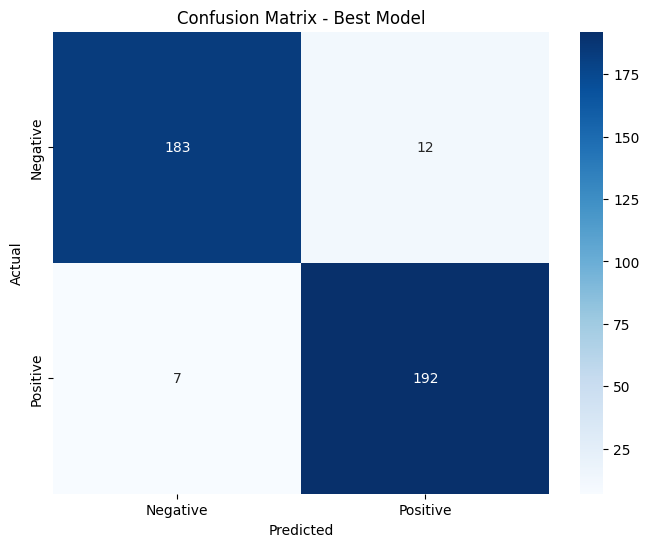


Cross-Validation F1 Scores: [0.9691358  0.95652174 0.94578313 0.95384615 0.94512195]
Mean CV F1: 0.9541 (Std: 0.0087)


In [18]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()

# Cross-validation to confirm performance (avoids test set overfitting)
cv_scores = cross_val_score(best_model, X_train_tfidf, y_train, cv=5, scoring='f1')
print(f"\nCross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (Std: {cv_scores.std():.4f})")